# Brand Sentiment Analysis — Twitter
**Prepared by:** Jasline Mwita 
**Client brief:** A major US airline wants to understand how it compares to competitors on Twitter — what drives positive and negative sentiment, and where to focus reputation management efforts.

**Dataset:** 14,640 real tweets across 6 US airlines, labeled positive / neutral / negative.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']  = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

GREEN  = '#2d6a4f'
GREENL = '#52b788'
RED    = '#e63946'
AMBER  = '#f4a261'
COLORS = {'positive': GREENL, 'neutral': '#adb5bd', 'negative': RED}

df = pd.read_csv(RAW / 'Tweets.csv', parse_dates=['tweet_created'])
df = df[['tweet_id','airline_sentiment','airline_sentiment_confidence',
         'negativereason','airline','text','tweet_created','retweet_count']].copy()
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
df['hour'] = df['tweet_created'].dt.hour
df['date'] = df['tweet_created'].dt.date

print(f'Tweets loaded:  {len(df):,}')
print(f'Airlines:       {df["airline"].nunique()}')
print(f'Date range:     {df["tweet_created"].min().date()} → {df["tweet_created"].max().date()}')
print(f'\nSentiment split:')
print(df['airline_sentiment'].value_counts())

Tweets loaded:  14,640
Airlines:       6
Date range:     2015-02-17 → 2015-02-24

Sentiment split:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


---
## Part 1 — Overall Sentiment Landscape

> **Analyst note:** The platform skews heavily negative (63%). This is typical for airline Twitter — customers who tweet are disproportionately those who had a bad experience. The benchmark isn't 50/50; it's how each airline performs *relative to the others*.

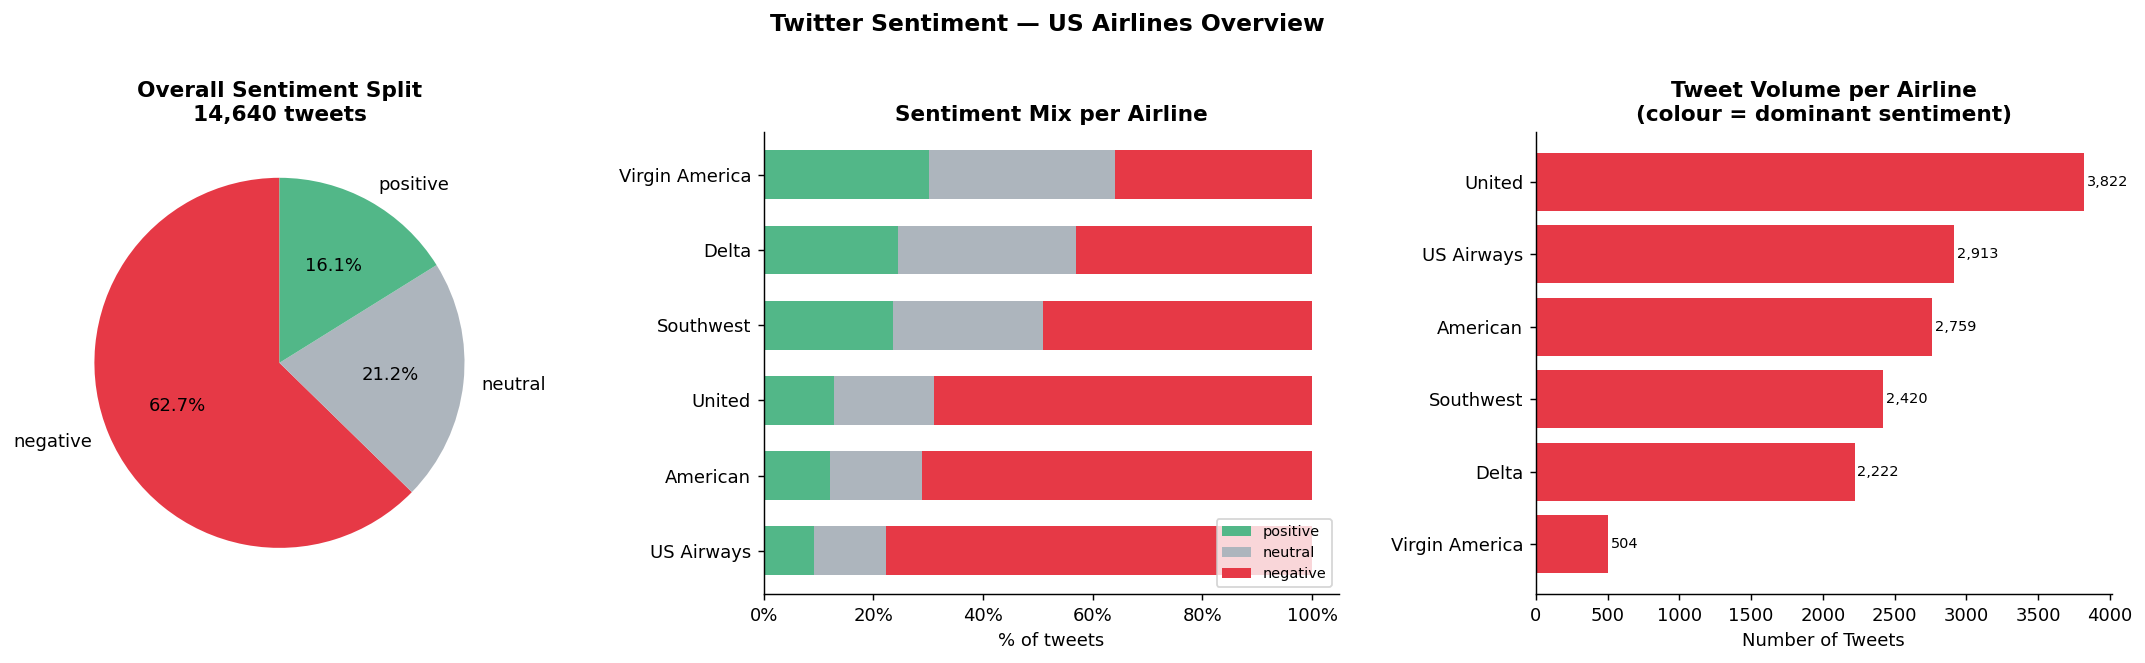

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Overall donut
sentiment_counts = df['airline_sentiment'].value_counts()
wedge_colors = [COLORS[s] for s in sentiment_counts.index]
axes[0].pie(sentiment_counts, labels=sentiment_counts.index,
            colors=wedge_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'linewidth':0},
            textprops={'fontsize': 10})
axes[0].set_title('Overall Sentiment Split\n14,640 tweets', fontweight='bold')

# Per-airline stacked bar
airline_sent = df.groupby(['airline','airline_sentiment']).size().unstack(fill_value=0)
airline_sent_pct = airline_sent.div(airline_sent.sum(axis=1), axis=0) * 100
airline_sent_pct = airline_sent_pct[['positive','neutral','negative']]
airline_sent_pct.sort_values('positive', ascending=True).plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[GREENL,'#adb5bd',RED], edgecolor='none', width=0.65
)
axes[1].set_xlabel('% of tweets')
axes[1].set_title('Sentiment Mix per Airline', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_ylabel('')

# Tweet volume per airline coloured by dominant sentiment
vol = df.groupby('airline').size().sort_values(ascending=True)
dom_sentiment = df.groupby('airline')['airline_sentiment'].agg(lambda x: x.value_counts().index[0])
vol_colors = [COLORS[dom_sentiment[a]] for a in vol.index]
bars = axes[2].barh(vol.index, vol.values, color=vol_colors, edgecolor='none')
axes[2].set_title('Tweet Volume per Airline\n(colour = dominant sentiment)', fontweight='bold')
axes[2].set_xlabel('Number of Tweets')
for bar, val in zip(bars, vol.values):
    axes[2].text(val + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

plt.suptitle('Twitter Sentiment — US Airlines Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED / 'sentiment_overview.png', bbox_inches='tight')
plt.show()

---
## Part 2 — Brand Health Score

A single composite metric per airline. Calculated as:

```
Brand Health Score = (positive_tweets - negative_tweets) / total_tweets × 100
```

Range: **−100** (all negative) → **+100** (all positive). Gives leadership a single number to track.

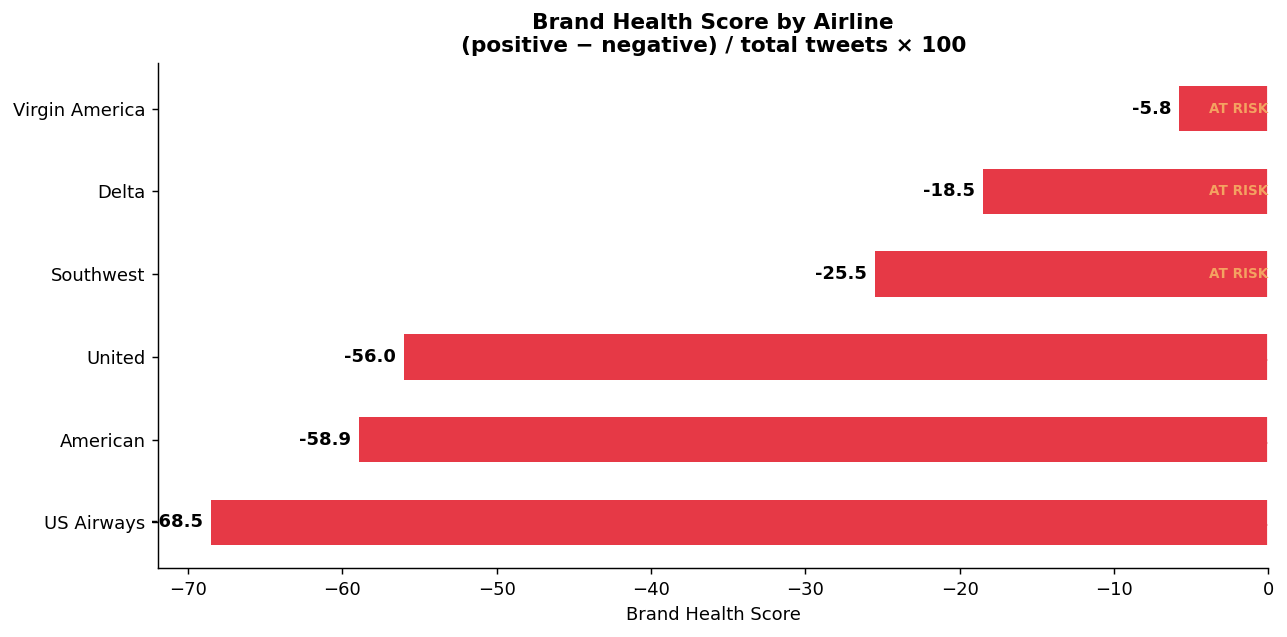

=== Brand Health Scores ===
Virgin America    -5.8  ██
Delta            -18.5  █████████
Southwest        -25.5  ████████████
United           -56.0  ████████████████████████████
American         -58.9  █████████████████████████████
US Airways       -68.5  ██████████████████████████████████


In [3]:
bhs = df.groupby('airline').apply(
    lambda x: (x['airline_sentiment'].eq('positive').sum() -
               x['airline_sentiment'].eq('negative').sum()) / len(x) * 100
).round(1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [GREENL if v >= 0 else RED for v in bhs.values]
bars = ax.barh(bhs.index, bhs.values, color=bar_colors, edgecolor='none', height=0.55)
ax.axvline(0, color='white', linewidth=1)
ax.set_xlabel('Brand Health Score')
ax.set_title('Brand Health Score by Airline\n(positive − negative) / total tweets × 100',
             fontweight='bold', fontsize=12)
for bar, val in zip(bars, bhs.values):
    ax.text(val + (0.5 if val >= 0 else -0.5),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', fontweight='bold',
            ha='left' if val >= 0 else 'right', fontsize=10)

# Add rating labels
for i, (airline, score) in enumerate(bhs.items()):
    rating = 'GOOD' if score > 0 else 'AT RISK' if score > -30 else 'CRITICAL'
    color  = GREENL if score > 0 else AMBER if score > -30 else RED
    ax.text(ax.get_xlim()[1] * 0.98, i, rating,
            va='center', ha='right', fontsize=7.5,
            fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(PROCESSED / 'brand_health_score.png', bbox_inches='tight')
plt.show()

print('=== Brand Health Scores ===')
for airline, score in bhs.sort_values(ascending=False).items():
    bar = '█' * int(abs(score) / 2)
    print(f'{airline:<15} {score:>+6.1f}  {bar}')

---
## Part 3 — Why Do People Complain?

The `negativereason` column is the most valuable field in this dataset. It tells us exactly what drove each negative tweet — delay, customer service, lost luggage, etc.

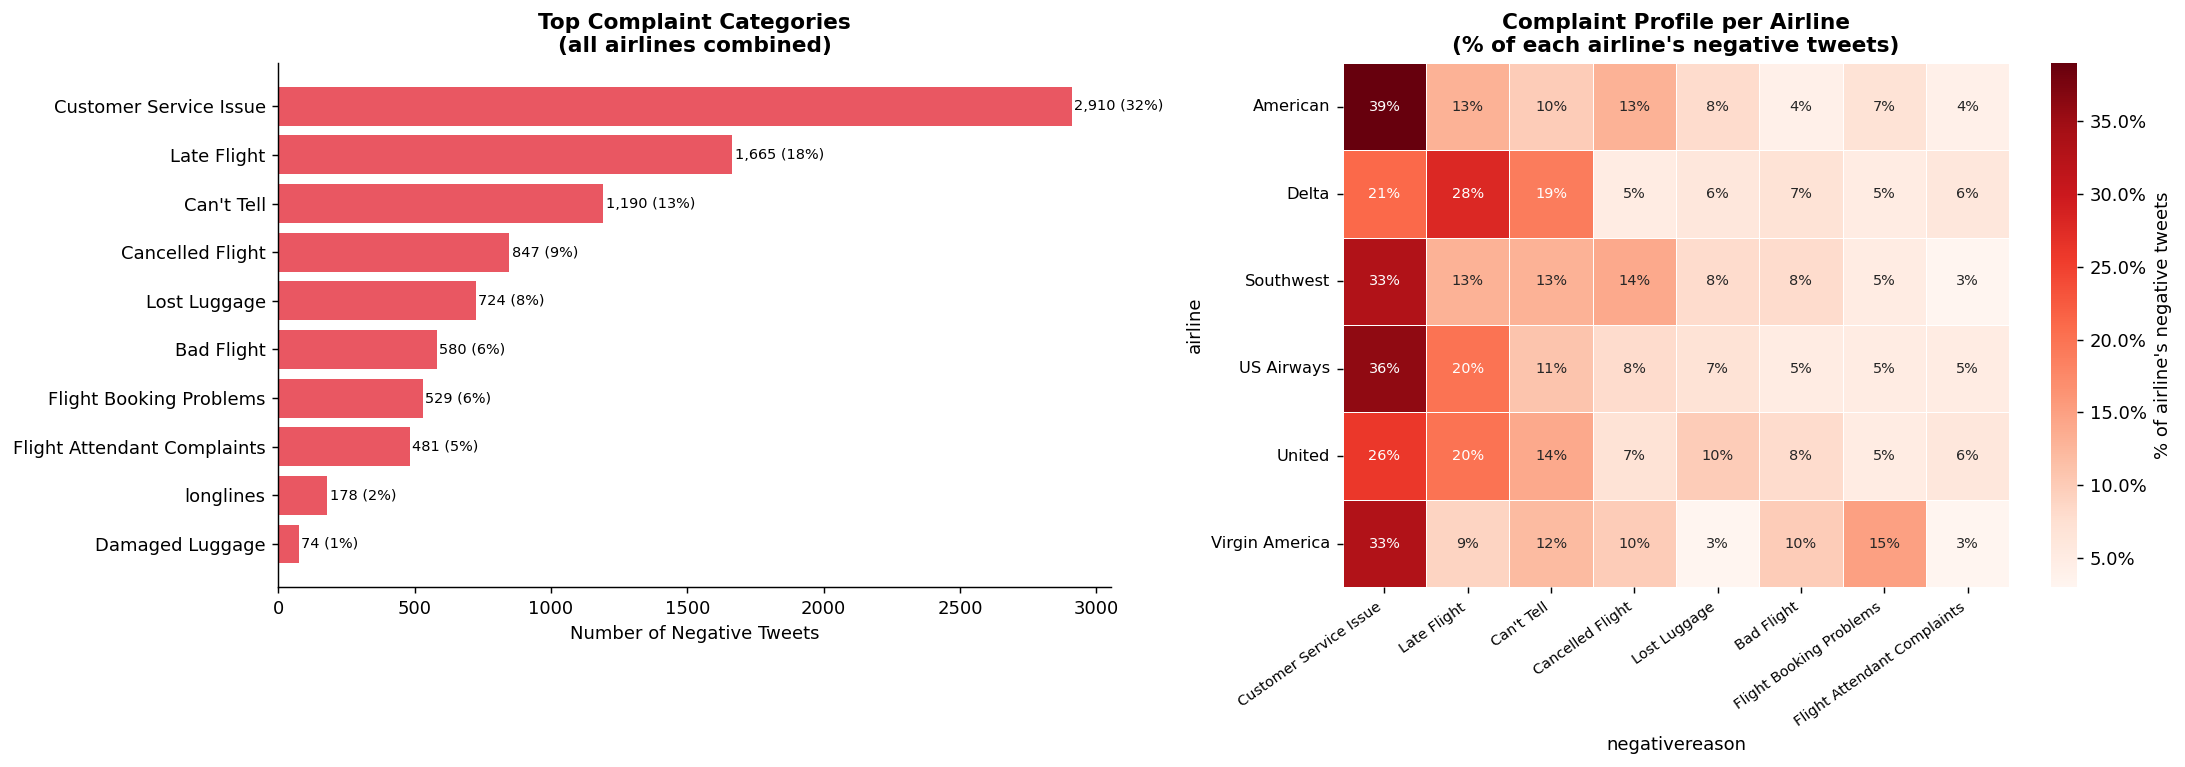

Top complaint: "Customer Service Issue" — 32% of all negative tweets


In [4]:
neg_df = df[df['airline_sentiment'] == 'negative'].copy()
neg_reasons = neg_df['negativereason'].value_counts().dropna()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Overall negative reasons
bars = axes[0].barh(neg_reasons.index[::-1], neg_reasons.values[::-1],
                    color=RED, edgecolor='none', alpha=0.85)
axes[0].set_title('Top Complaint Categories\n(all airlines combined)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Negative Tweets')
for bar, val in zip(bars, neg_reasons.values[::-1]):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/len(neg_df):.0%})', va='center', fontsize=8)

# Heatmap: reason by airline
reason_airline = neg_df.groupby(['airline','negativereason']).size().unstack(fill_value=0)
reason_airline_pct = reason_airline.div(reason_airline.sum(axis=1), axis=0).round(2)
top_reasons = neg_reasons.head(8).index
plot_heat = reason_airline_pct[top_reasons]
sns.heatmap(plot_heat, ax=axes[1], cmap='Reds', annot=True,
            fmt='.0%', linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'label': '% of airline\'s negative tweets', 'format': mtick.PercentFormatter(xmax=1)})
axes[1].set_title('Complaint Profile per Airline\n(% of each airline\'s negative tweets)',
                  fontweight='bold', fontsize=12)
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED / 'complaint_analysis.png', bbox_inches='tight')
plt.show()

print(f'Top complaint: "{neg_reasons.index[0]}" — {neg_reasons.iloc[0]/len(neg_df):.0%} of all negative tweets')

---
## Part 4 — Sentiment by Time of Day

Are people more positive or negative at certain times? This can inform when customer service teams should be most active.

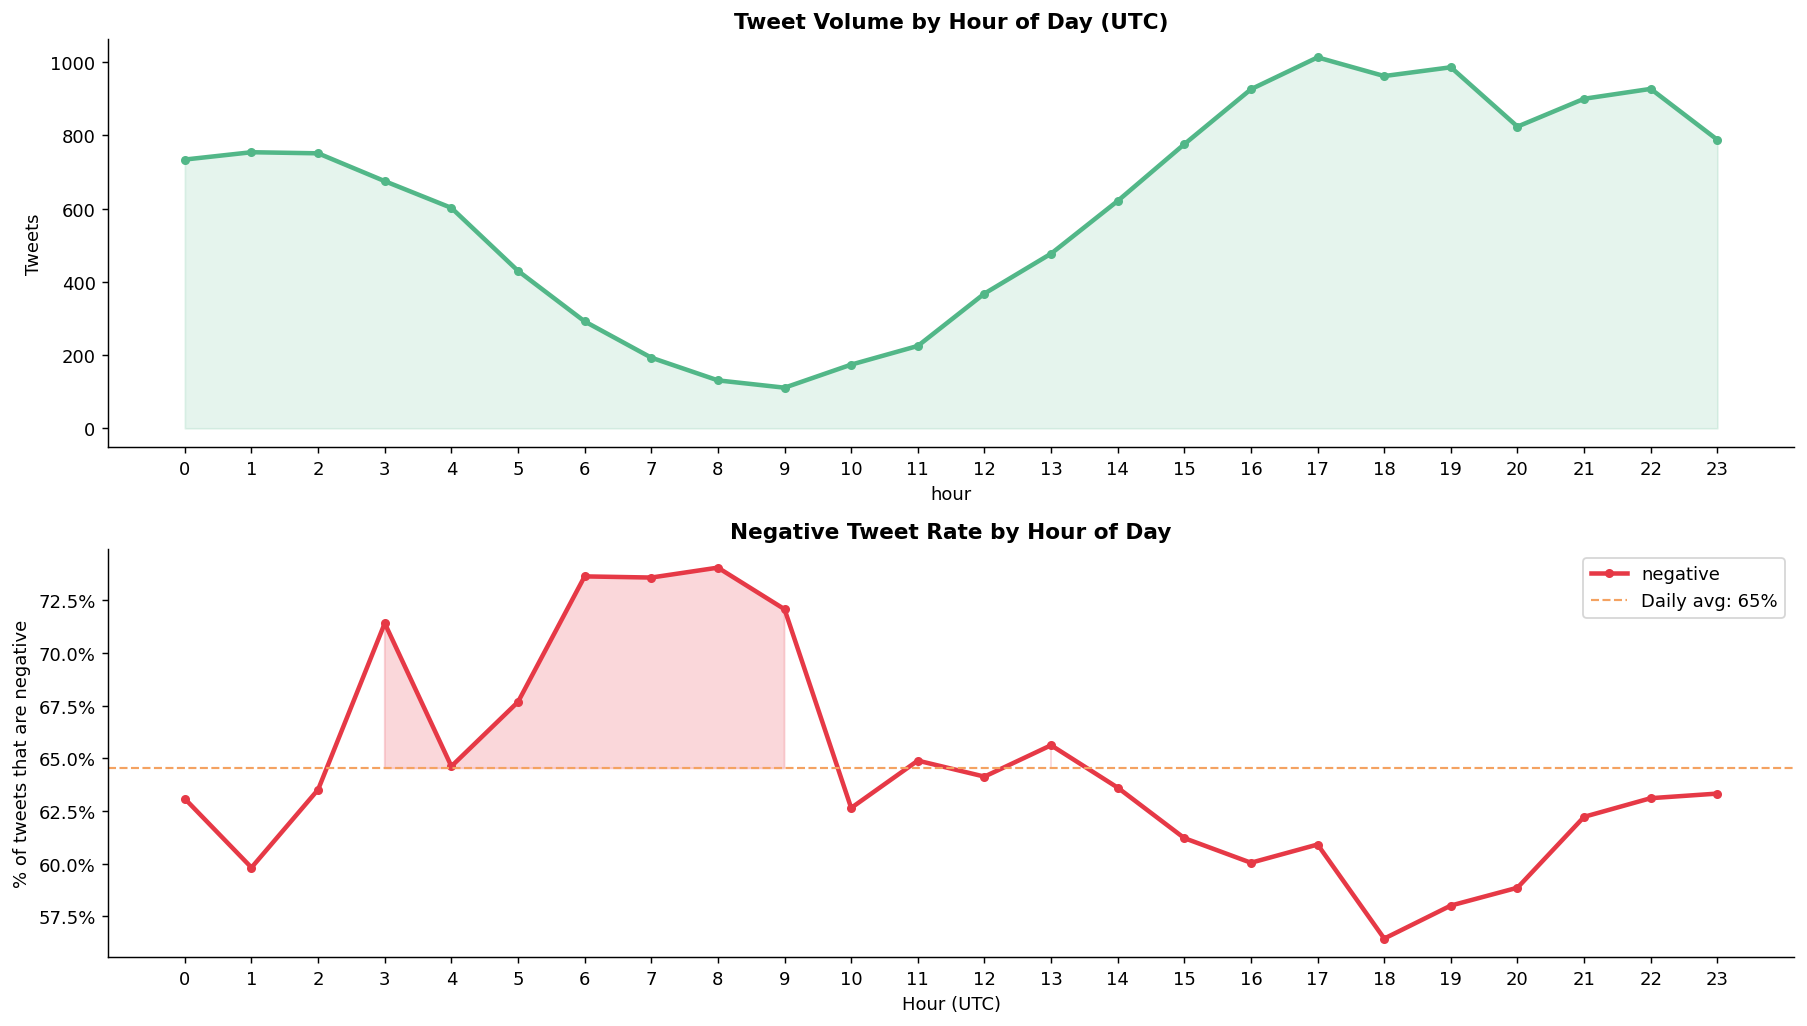

Highest negative rate: Hour 8:00 UTC (74% negative)
Most active hour: Hour 17:00 UTC


In [5]:
hourly = df.groupby(['hour','airline_sentiment']).size().unstack(fill_value=0)
hourly_pct = hourly.div(hourly.sum(axis=1), axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Volume by hour
hourly.sum(axis=1).plot(ax=axes[0], color=GREENL, linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Tweet Volume by Hour of Day (UTC)', fontweight='bold')
axes[0].set_ylabel('Tweets')
axes[0].set_xticks(range(0,24))
axes[0].fill_between(hourly.sum(axis=1).index, hourly.sum(axis=1).values, alpha=0.15, color=GREENL)

# Negative rate by hour
hourly_pct['negative'].plot(ax=axes[1], color=RED, linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(hourly_pct['negative'].mean(), color=AMBER, linestyle='--', linewidth=1.2,
                label=f'Daily avg: {hourly_pct["negative"].mean():.0%}')
axes[1].set_title('Negative Tweet Rate by Hour of Day', fontweight='bold')
axes[1].set_ylabel('% of tweets that are negative')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_xticks(range(0,24))
axes[1].set_xlabel('Hour (UTC)')
axes[1].legend()
axes[1].fill_between(hourly_pct['negative'].index, hourly_pct['negative'].values,
                     hourly_pct['negative'].mean(), where=hourly_pct['negative'] > hourly_pct['negative'].mean(),
                     alpha=0.2, color=RED, label='Above average')

plt.tight_layout()
plt.savefig(PROCESSED / 'sentiment_by_hour.png', bbox_inches='tight')
plt.show()

worst_hour = hourly_pct['negative'].idxmax()
print(f'Highest negative rate: Hour {worst_hour}:00 UTC ({hourly_pct["negative"].max():.0%} negative)')
print(f'Most active hour: Hour {hourly.sum(axis=1).idxmax()}:00 UTC')

In [6]:
# Export cleaned data for notebook 2
df.to_csv(PROCESSED / 'tweets_clean.csv', index=False)
print(f'Exported {len(df):,} tweets to processed/')

print('\n=== Summary for Client Brief ===')
print(f'Total tweets analysed: {len(df):,}')
print(f'Platform skew: {df["airline_sentiment"].value_counts(normalize=True)["negative"]:.0%} negative overall')
print(f'Best performer:  {bhs.idxmax()} (BHS: {bhs.max():+.1f})')
print(f'Worst performer: {bhs.idxmin()} (BHS: {bhs.min():+.1f})')
print(f'Top complaint driver: {neg_reasons.index[0]} ({neg_reasons.iloc[0]/len(neg_df):.0%} of negatives)')

Exported 14,640 tweets to processed/

=== Summary for Client Brief ===
Total tweets analysed: 14,640


Platform skew: 63% negative overall
Best performer:  Virgin America (BHS: -5.8)
Worst performer: US Airways (BHS: -68.5)
Top complaint driver: Customer Service Issue (32% of negatives)
